<a href="https://colab.research.google.com/github/rahul4bisht/House-Price-Prediction/blob/main/Task2_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# House Price Prediction Project
# Import Required Libraries
# ==============================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset

df = pd.read_csv("/content/data.csv")

In [ ]:
# Display first 5 rows of the dataset

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [ ]:
# Statistical summary of numerical columns

df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [ ]:
# Check missing values in each column

df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
# Total missing values in the dataset

print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [ ]:
# Check duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Display all column names

df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

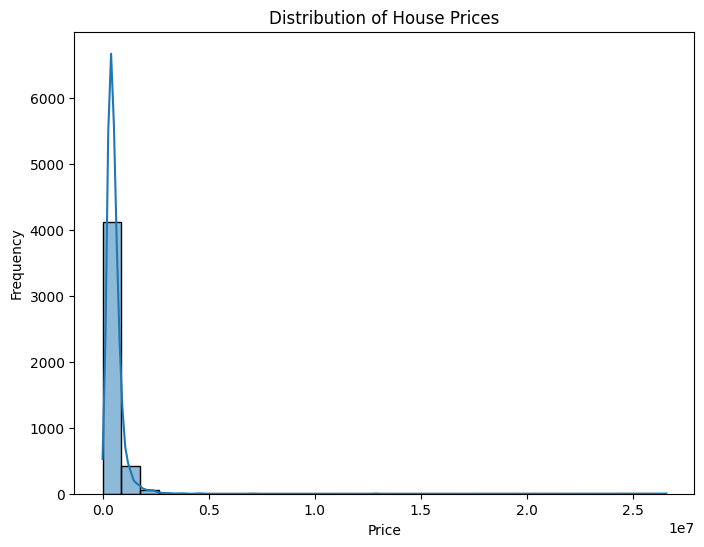

In [ ]:
# Distribution of House Prices

plt.figure(figsize=(8,6))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Apply log transformation to the target variable (price)

df['price'] = np.log1p(df['price'])

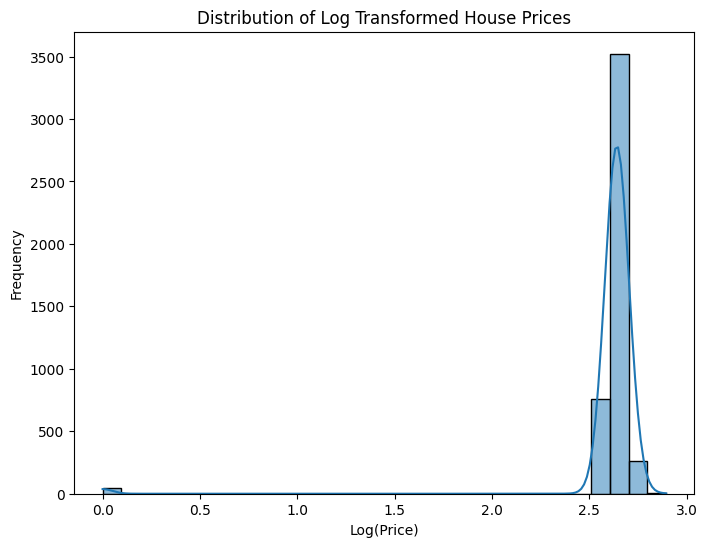

In [ ]:
# Distribution after Log Transformation

plt.figure(figsize=(8,6))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of Log Transformed House Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")

plt.show()

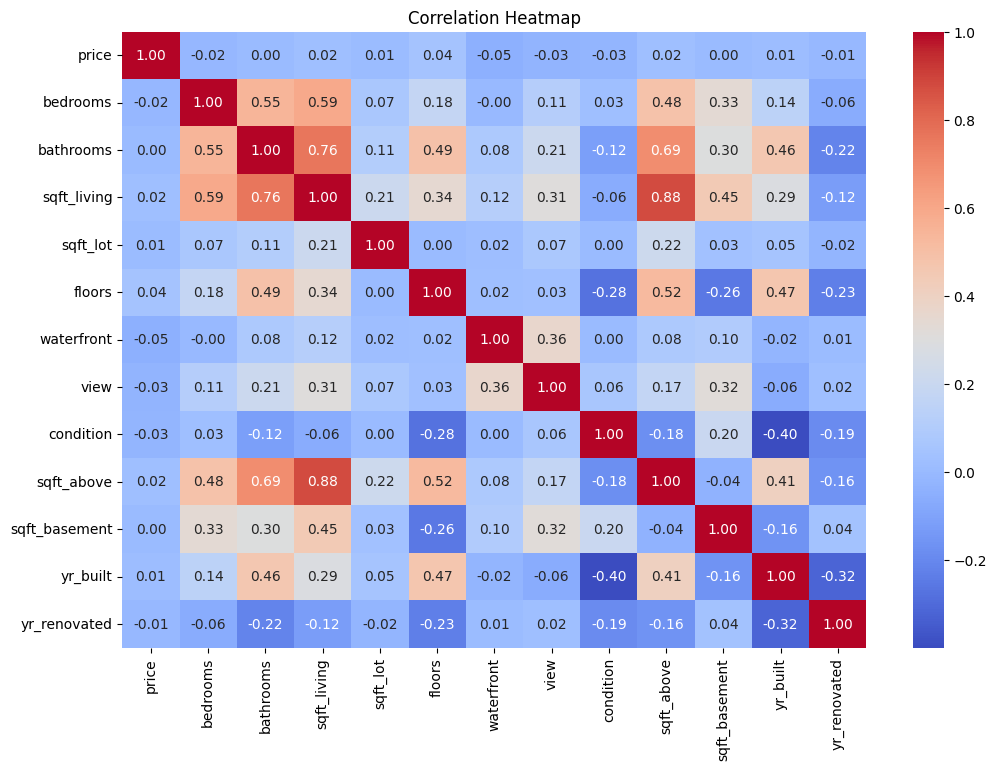

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

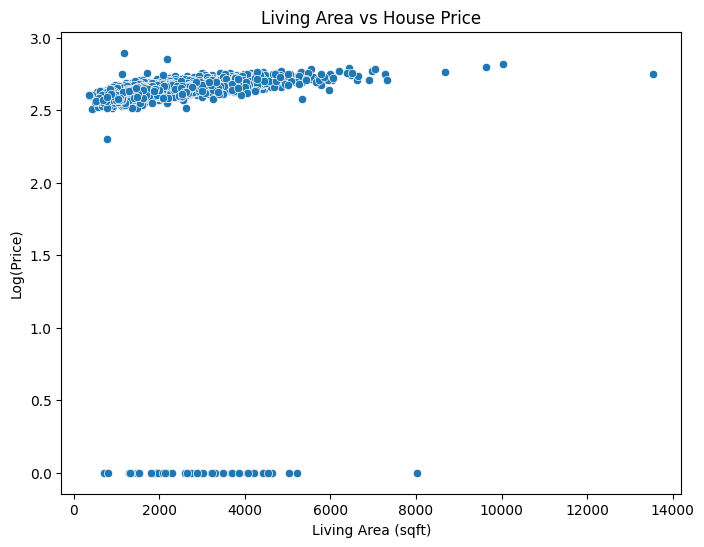

In [ ]:
# Relationship between Living Area and House Price

plt.figure(figsize=(8,6))

sns.scatterplot(x='sqft_living', y='price', data=df)

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Log(Price)")

plt.show()

In [ ]:
# Boxplot for House Prices

plt.figure(figsize=(8,6))

sns.boxplot(y=df['price'])

plt.title("Boxplot of Log Transformed House Prices")

plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Convert date column to datetime format

df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Extract useful features from date

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [ ]:
# Drop original date column

df.drop('date', axis=1, inplace=True)

In [ ]:
df[['street','city','statezip','country']].nunique()

NameError: name 'df' is not defined

In [ ]:
# Drop unnecessary columns

df.drop(['street', 'country'], axis=1, inplace=True)

In [ ]:
# Encode categorical columns

label_encoder = LabelEncoder()

df['city'] = label_encoder.fit_transform(df['city'])
df['statezip'] = label_encoder.fit_transform(df['statezip'])

NameError: name 'LabelEncoder' is not defined

In [ ]:
# Separate features (X) and target (y)

X = df.drop('price', axis=1)
y = df['price']

NameError: name 'df' is not defined

In [ ]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

NameError: name 'StandardScaler' is not defined

In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'train_test_split' is not defined

In [ ]:
# Train Linear Regression Model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

NameError: name 'LinearRegression' is not defined

In [ ]:
# Predict on test data

lr_predictions = lr_model.predict(X_test)

NameError: name 'lr_model' is not defined

In [ ]:
# Evaluate Linear Regression Model

mae = mean_absolute_error(y_test, lr_predictions)
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

NameError: name 'mean_absolute_error' is not defined

In [ ]:
# Train Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

NameError: name 'RandomForestRegressor' is not defined

In [ ]:
# Predictions using Random Forest

rf_predictions = rf_model.predict(X_test)

In [ ]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

NameError: name 'mean_absolute_error' is not defined

In [ ]:
# Train Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

NameError: name 'GradientBoostingRegressor' is not defined

In [ ]:
# Predictions using Gradient Boosting

gb_predictions = gb_model.predict(X_test)

NameError: name 'gb_model' is not defined

In [ ]:
# Evaluate Gradient Boosting

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

NameError: name 'mean_absolute_error' is not defined

In [ ]:
# Compare all models

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae, rf_mae, gb_mae],
    'RMSE': [rmse, rf_rmse, gb_rmse],
    'R2 Score': [r2, rf_r2, gb_r2]
})

results.sort_values(by='RMSE')

NameError: name 'pd' is not defined

In [ ]:
# Residual Analysis

residuals = y_test - lr_predictions

plt.figure(figsize=(8,6))
sns.scatterplot(x=lr_predictions, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

NameError: name 'y_test' is not defined

In [ ]:
# Compare all models

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae, rf_mae, gb_mae],
    "RMSE": [rmse, rf_rmse, gb_rmse],
    "R2 Score": [r2, rf_r2, gb_r2]
})

results

NameError: name 'pd' is not defined

In [ ]:
# Best model based on RMSE

best_model = results.loc[results["RMSE"].idxmin()]

print(best_model)

NameError: name 'results' is not defined

In [ ]:
# Residual Analysis

residuals = y_test - lr_predictions

plt.figure(figsize=(8,6))

plt.scatter(lr_predictions, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

NameError: name 'y_test' is not defined

In [ ]:
# Save the best model

joblib.dump(lr_model, "house_price_model.pkl")

print("Model Saved Successfully")

NameError: name 'joblib' is not defined

In [ ]:
# Example prediction

sample_house = X.iloc[[0]]

sample_house_scaled = scaler.transform(sample_house)

prediction = lr_model.predict(sample_house_scaled)

print("Predicted House Price (Log Scale):", prediction[0])
print("Predicted House Price:", np.expm1(prediction[0]))

NameError: name 'X' is not defined